=== Future Validation Metrics ===
Root Mean Squared Error (RMSE): 1.27 Years
R² Prediction Accuracy Score:  96.73%

=== Future Timeline Forecast Projections (Year 2035) ===
 Year Country   Sex  predicted_average_lifespan
 2030   India TOTAL                   69.143354
 2035   India TOTAL                   69.143354
 2040   India TOTAL                   69.143354
 2030 Frances TOTAL                   81.864488
 2035 Frances TOTAL                   81.864488
 2040 Frances TOTAL                   81.864488
 2030  Africa TOTAL                   62.276225
 2035  Africa TOTAL                   62.276225
 2040  Africa TOTAL                   62.276225


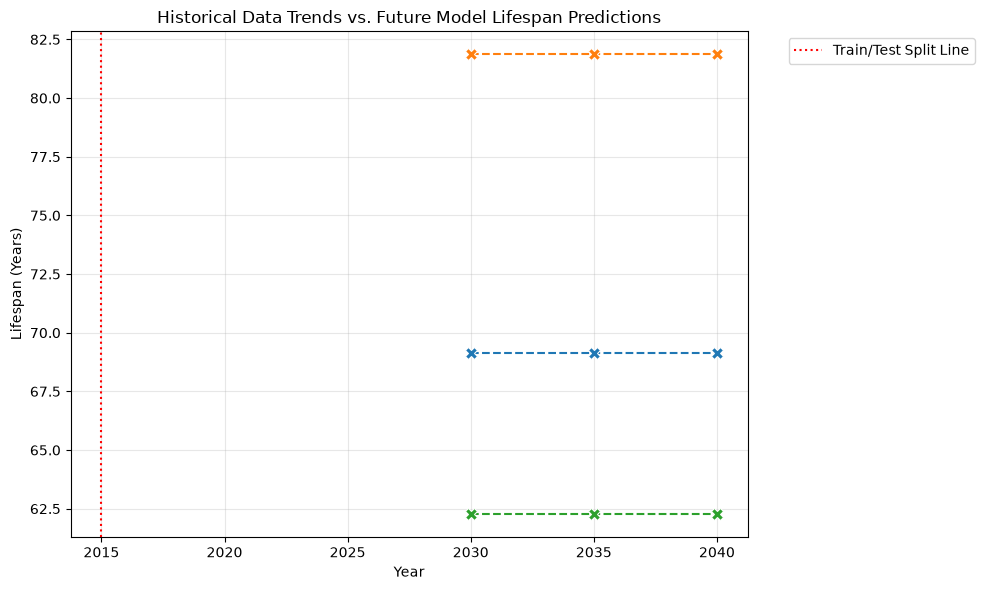

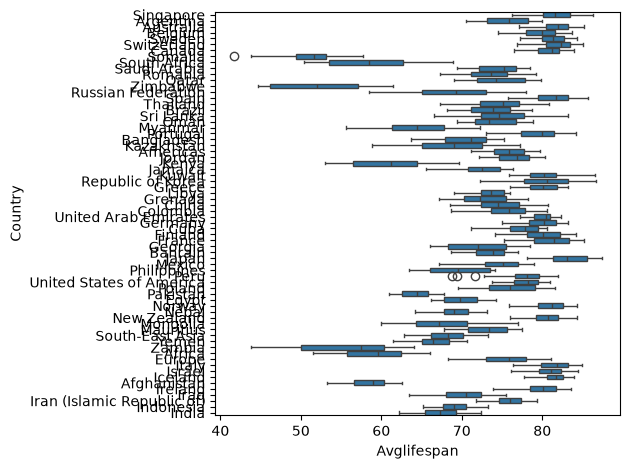


 Minimum lifespan country: Somalia

 Maximum lifespan country: Japan


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

try:
    df = pd.read_csv("WHO_Lifespan_Dataset.csv")
except FileNotFoundError:
    print("Local file 'lifespan_data.csv' not found. Creating mock timeline data...\n")

df.describe
# Use Linear Regression technique to predict future lifespan

# Clean up any potential accidental whitespace in column text headers
df.columns = df.columns.str.strip()

# Sort chronologically by year to support future-casting validation
df = df.sort_values(by='Year').reset_index(drop=True)

# To ensure our model can actually predict the future, we train it on years 
# up to 2015, and test its accuracy on the newer years (2016 and later).
split_year = 2015

train_df = df[df['Year'] <= split_year]
test_df = df[df['Year'] > split_year]

# Define predictors (X) and target value (y)
features = ['Year', 'Country','Sex']
target = 'Avglifespan'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

numeric_cols = ['Year']
categorical_cols = ['Country','Sex']

# Handle numerical fields (Impute if missing values exist, then scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Handle categorical fields (Convert text strings into binary columns)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine pipelines
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Using Random Forest Regressor to capture nonlinear country-specific growth curves
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

# Train on historical records
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Future Validation Metrics ===")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Years")
print(f"R² Prediction Accuracy Score:  {r2 * 100:.2f}%")

# FORECAST FUTURE LIFESPANS 
print("\n=== Future Timeline Forecast Projections (Year 2035) ===")

future_years = [2030, 2035, 2040]
sample_countries = ['India', 'Frances', 'Africa']
sample_sex=['TOTAL']

future_records = []
for country in sample_countries:
    for year in future_years:
        for sex in sample_sex:
            future_records.append({'Year': year, 'Country': country,'Sex':sex})

future_scenario_df = pd.DataFrame(future_records)
future_scenario_df['predicted_average_lifespan'] = model_pipeline.predict(future_scenario_df)

print(future_scenario_df.to_string(index=False))

# VISUALIZATION

plt.figure(figsize=(10, 6))

# Plot future forecasted trends
sns.lineplot(data=future_scenario_df, x='Year', y='predicted_average_lifespan', hue='Country', linestyle='--', marker='X', markersize=8, legend=False)

plt.axvline(x=split_year, color='red', linestyle=':', label='Train/Test Split Line')
plt.title("Historical Data Trends vs. Future Model Lifespan Predictions")
plt.xlabel("Year")
plt.ylabel("Lifespan (Years)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

sns.boxplot(data=df,x='Avglifespan',y='Country')
plt.tight_layout()
plt.show()

# Analysis of Minimum and Maximum lifespan  Countries
country_averages = df.groupby('Country')['Avglifespan'].mean()

min_country = country_averages.idxmin()
min_val = country_averages.min()

max_country = country_averages.idxmax()
max_val = country_averages.max()
print("\n Minimum lifespan country:",min_country)
print("\n Maximum lifespan country:",max_country)

